In [ ]:
# EDA Step 1 - Extract the csv data and start performing initial EDA
import sys 
import os 

sys.path.append(os.path.abspath("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/src"))

from data_preprocessing import load_data, merge_data, create_order_total

orders, order_items, customers, reviews, products = load_data("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Raw Datasets")
df = merge_data(orders, order_items, customers, reviews, products)
df = create_order_total(df)

df.head()
df.info()
df.describe()

df.to_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/cleaned_data.csv", index = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   order_item_id                  113314 non-null  int64  
 2   product_id                     113314 non-null  object 
 3   seller_id                      113314 non-null  object 
 4   shipping_limit_date            113314 non-null  object 
 5   price                          113314 non-null  float64
 6   freight_value                  113314 non-null  float64
 7   customer_id                    113314 non-null  object 
 8   order_status                   113314 non-null  object 
 9   order_purchase_timestamp       113314 non-null  object 
 10  order_approved_at              113299 non-null  object 
 11  order_delivered_carrier_date   112111 non-null  object 
 12  order_delivered_customer_date 

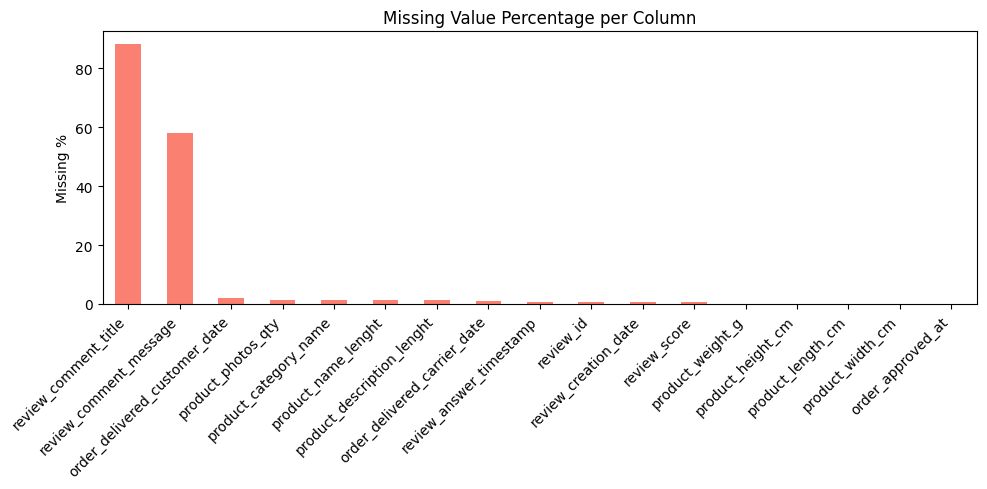

review_comment_title             88.144448
review_comment_message           57.955769
order_delivered_customer_date     2.184196
product_photos_qty                1.422596
product_category_name             1.422596
product_name_lenght               1.422596
product_description_lenght        1.422596
order_delivered_carrier_date      1.061652
review_answer_timestamp           0.831318
review_id                         0.831318
review_creation_date              0.831318
review_score                      0.831318
product_weight_g                  0.015885
product_height_cm                 0.015885
product_length_cm                 0.015885
product_width_cm                  0.015885
order_approved_at                 0.013238
dtype: float64


In [2]:
# EDA Step 2 - Missing Value Analysis
import matplotlib.pyplot as plt
import seaborn as sns

missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False)

if missing_df.empty:
    print('No missing values found in the dataset!')
else:
    plt.figure(figsize=(10, 5))
    missing_df.plot(kind='bar', color='salmon')
    plt.title('Missing Value Percentage per Column')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(missing_df)

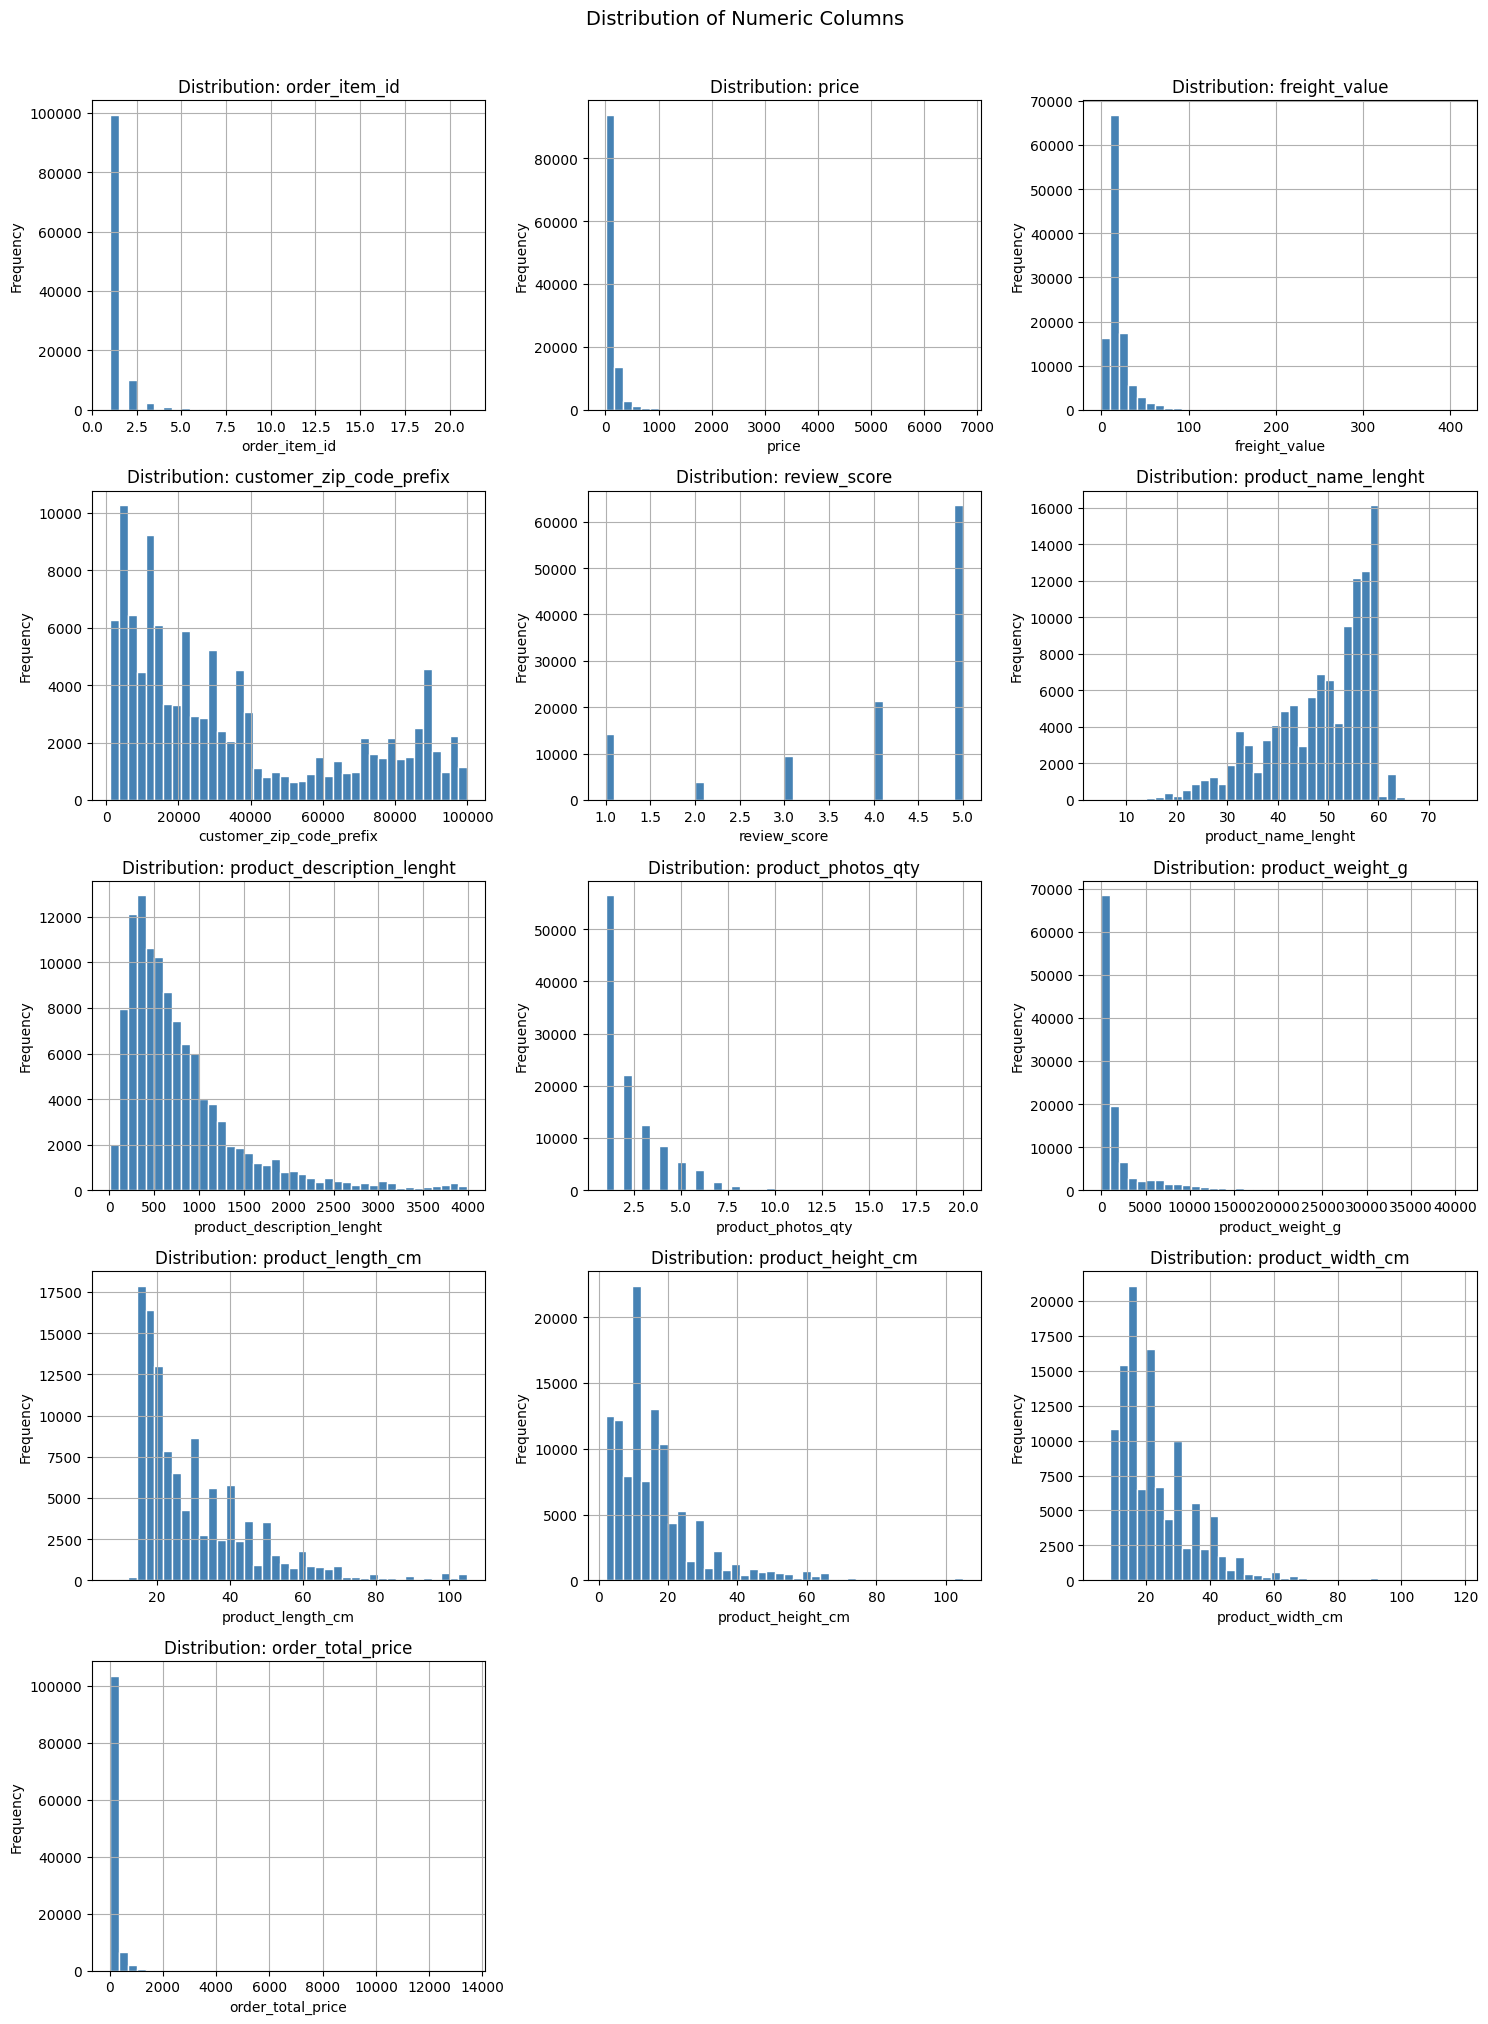

In [3]:
# EDA Step 3 - Distribution of Numeric Columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].dropna().hist(bins = 40, ax = axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

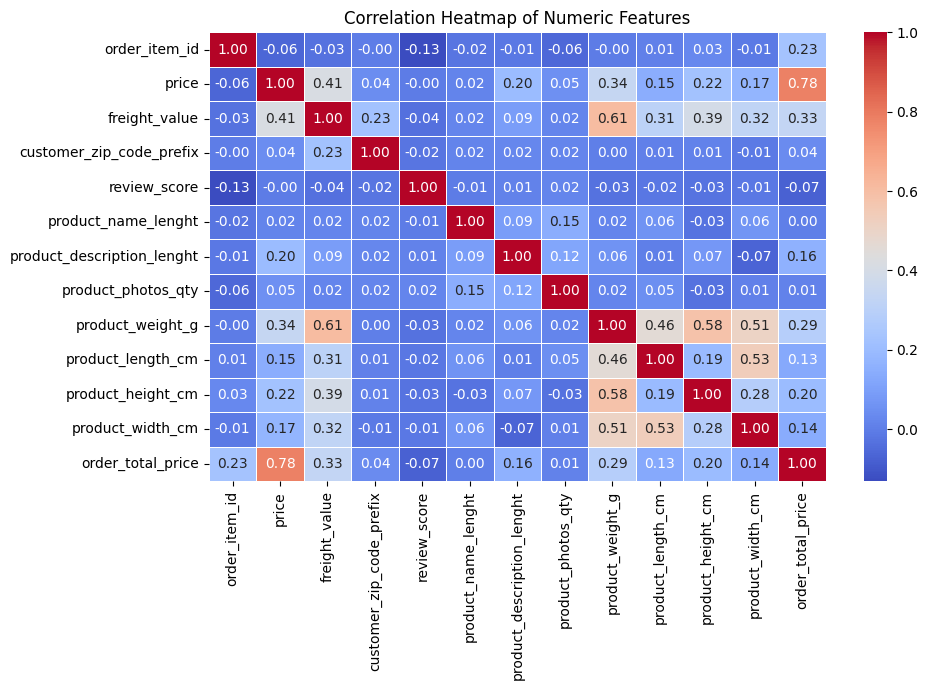

In [4]:
# EDA Step 4 - Correlation Heatmap
corr = df[numeric_cols].corr()

plt.figure(figsize = (10, 7))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

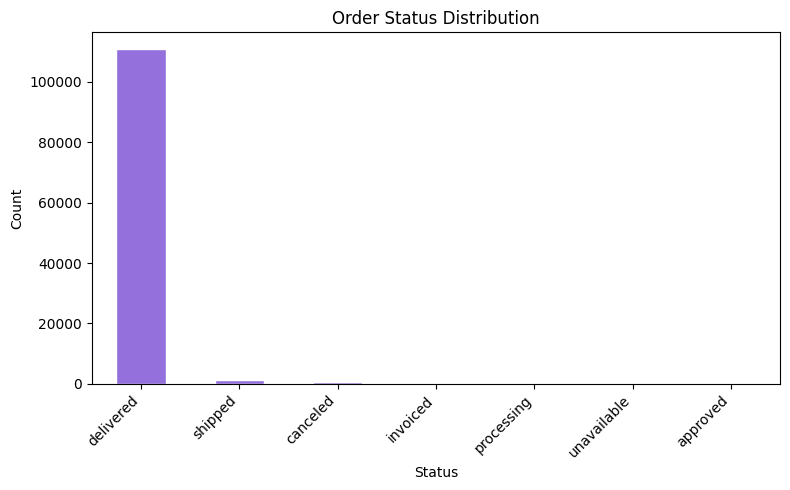

order_status
delivered      110840
shipped          1196
canceled          546
invoiced          364
processing        358
unavailable         7
approved            3
Name: count, dtype: int64


In [5]:
# EDA Step 5 - Order Status Breakdown
if 'order_status' in df.columns:
    status_counts = df['order_status'].value_counts()
    plt.figure(figsize = (8, 5))
    status_counts.plot(kind = 'bar', color = 'mediumpurple', edgecolor = 'white')
    plt.title('Order Status Distribution')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.show()
    print(status_counts)

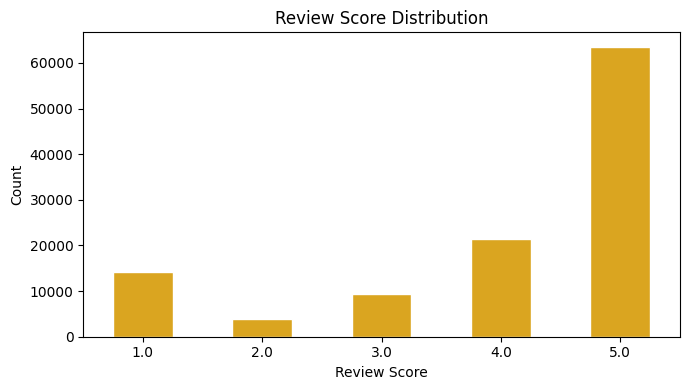

review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64


In [6]:
# EDA Step 6 - Review Score Distribution
if 'review_score' in df.columns:
    score_counts = df['review_score'].value_counts().sort_index()
    plt.figure(figsize = (7, 4))
    score_counts.plot(kind = 'bar', color = 'goldenrod', edgecolor = 'white')
    plt.title('Review Score Distribution')
    plt.xlabel('Review Score')
    plt.ylabel('Count')
    plt.xticks(rotation = 0)
    plt.tight_layout()
    plt.show()
    print(score_counts)

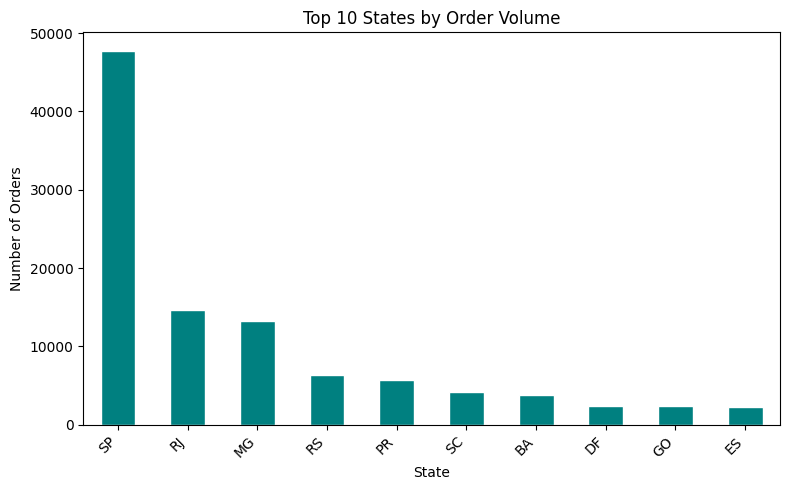

customer_state
SP    47720
RJ    14668
MG    13209
RS     6287
PR     5764
SC     4191
BA     3819
DF     2433
GO     2353
ES     2269
Name: count, dtype: int64


In [7]:
# EDA Step 7 - Geographic Distribution (Top 10 States)
if 'customer_state' in df.columns:
    top_states = df['customer_state'].value_counts().head(10)
    plt.figure(figsize = (8, 5))
    top_states.plot(kind='bar', color='teal', edgecolor='white')
    plt.title('Top 10 States by Order Volume')
    plt.xlabel('State')
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(top_states)